In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
data1 = pd.read_csv('test.csv', encoding='utf-8')
data1['type'] = 'test'

data2 = pd.read_csv('train.csv', encoding='utf-8')
data2['type'] = 'train'

data3 = pd.read_csv('valid.csv', encoding='utf-8')
data3['valid'] = 'valid'

datas = [data1, data2, data3]
data = pd.concat(datas, ignore_index=True)

In [53]:
data.head(1)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,1,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN


In [54]:
data['sum_true'] = data['true_counts'] + data['mostly_true_counts'] + data['half_true_counts']
data.head(1)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,1,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3


In [55]:
data['sum_false'] = data['mostly_false_counts'] + data['false_counts'] + data['pants_on_fire_counts']
data.head(1)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,1,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21


In [56]:
data['result'] = data['sum_true'] > data['sum_false']
data.head(4)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,245,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,53,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,1,1,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False


In [57]:
data.groupby('result').agg({'context': 'count'})

,context
result,
False,13128
True,9680


<BarContainer object of 6 artists>

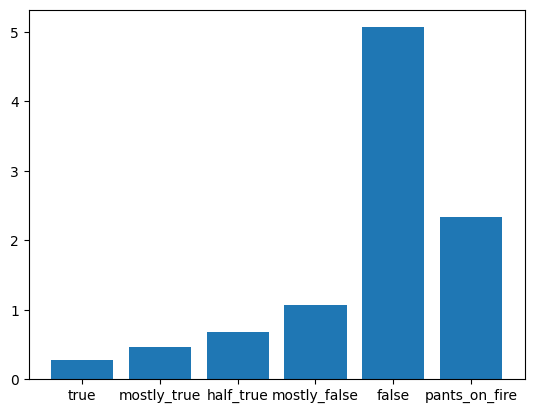

In [58]:
graf = {'true':data['true_counts'].sum() / 1000000,
'mostly_true':data['mostly_true_counts'].sum() / 1000000,
'half_true':data['half_true_counts'].sum() / 1000000,
'mostly_false':data['mostly_false_counts'].sum() / 1000000,
'false':data['false_counts'].sum() / 1000000,
'pants_on_fire':data['pants_on_fire_counts'].sum() / 1000000}

labels = list(graf.keys())
values = list(graf.values())


plt.bar(labels, values)

In [59]:
data.head(5)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,245,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,53,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,1,1,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False
4,3855,3,The Federal Register - which houses all Washin...,"June 14, 2011",regulation,randy forbes,Randy Forbes is from Chesapeake and represents...,virginia,5,3,...,1,0,0,a statement,To recap: To argue that regulation is out of c...,test,NaN,12,1,True


In [60]:
data['Words_Statement'] = data['statement'].str.split().str.len()
data.head(3)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13


In [61]:
data['Words_Statement'].median()

np.float64(16.0)

In [62]:
data_state = data.groupby(['state_info']).agg({'context': 'count'})
data_state

,context
state_info,
arizona,121
california,353
colorado,50
florida,1709
georgia,976
illinois,210
iowa,81
michigan,71
missouri,194


In [63]:
data_state.sort_values(by='context', ascending=False).head(7)

,context
state_info,
national,6045
wisconsin,1834
florida,1709
texas,1649
georgia,976
virginia,670
ohio,652


In [64]:
data.head(5)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,1,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False,13
4,3855,3,The Federal Register - which houses all Washin...,"June 14, 2011",regulation,randy forbes,Randy Forbes is from Chesapeake and represents...,virginia,5,3,...,0,0,a statement,To recap: To argue that regulation is out of c...,test,NaN,12,1,True,23


In [70]:
data.to_csv('data.csv')

In [66]:
data['Words_Justification'] = data['justification'].str.split().str.len()
data.head(4)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement,Words_Justification
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22,90
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6,47
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13,82
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False,13,112


In [67]:
data['Words_Justification'].median()

np.float64(88.0)

In [68]:

data['date'] = pd.to_datetime(data['date'])

data['year'] = data['date'].dt.year


In [69]:
exclude_years = [2000, 2002]
data = data[~data['year'].isin(exclude_years)]

data.groupby(['year']).agg({'id': 'count'})

,id
year,
2007,247
2008,552
2009,449
2010,1570
2011,1924
2012,1938
2013,1418
2014,1545
2015,1289
